# Task 2: Quantitative Analysis and Technical Indicators

This notebook loads daily OHLCV stock data, validates price fields, computes technical indicators, adds risk/return metrics, and visualizes how indicators relate to price action.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yfinance as yf

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loading import load_price_data, normalize_price_data
from src.indicators import DEFAULT_INDICATOR_PARAMS, add_daily_returns, add_technical_indicators
from src.quant_metrics import add_financial_metrics, add_pynance_metrics
from src.visualization import plot_price_indicators, save_current_figure

sns.set_theme(style='whitegrid')
RAW = PROJECT_ROOT / 'data' / 'raw'
FIGURES = PROJECT_ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## Load Price Data

Use a local CSV from `data/raw/prices/` when available. If no local file exists, download a reproducible sample with `yfinance`. `auto_adjust=False` keeps the `Adj Close` column required for return calculations.

In [2]:
TICKER = 'AAPL'
PRICE_FILE = RAW / 'prices' / f'{TICKER}.csv'

if PRICE_FILE.exists():
    prices = load_price_data(PRICE_FILE)
    data_source = f'local CSV: {PRICE_FILE}'
else:
    downloaded = yf.download(
        TICKER,
        start='2020-01-01',
        end='2026-01-01',
        auto_adjust=False,
        progress=False,
    ).reset_index()
    prices = normalize_price_data(downloaded)
    data_source = 'yfinance download: 2020-01-01 to 2026-01-01'

prices['stock'] = TICKER
print(data_source)
prices.head()

yfinance download: 2020-01-01 to 2026-01-01


,Date,Adj Close,Close,High,Low,Open,Volume,stock
0,2020-01-02,72.400513,75.087502,75.150002,73.797501,74.059998,135480400,AAPL
1,2020-01-03,71.696617,74.357498,75.144997,74.125000,74.287498,146322800,AAPL
2,2020-01-06,72.267929,74.949997,74.989998,73.187500,73.447502,118387200,AAPL
3,2020-01-07,71.928062,74.597504,75.224998,74.370003,74.959999,108872000,AAPL
4,2020-01-08,73.085121,75.797501,76.110001,74.290001,74.290001,132079200,AAPL


In [3]:
# Show the first few rows of the price data
display(prices.head())
# Show descriptive statistics for numeric columns
display(prices.describe())

,Date,Adj Close,Close,High,Low,Open,Volume,stock
0,2020-01-02,72.400513,75.087502,75.150002,73.797501,74.059998,135480400,AAPL
1,2020-01-03,71.696617,74.357498,75.144997,74.125000,74.287498,146322800,AAPL
2,2020-01-06,72.267929,74.949997,74.989998,73.187500,73.447502,118387200,AAPL
3,2020-01-07,71.928062,74.597504,75.224998,74.370003,74.959999,108872000,AAPL
4,2020-01-08,73.085121,75.797501,76.110001,74.290001,74.290001,132079200,AAPL


,Date,Adj Close,Close,High,Low,Open,Volume
count,1508,1508.000000,1508.000000,1508.000000,1508.000000,1508.000000,1.508000e+03
mean,2022-12-30 16:01:35,164.787443,167.061671,168.769448,165.185171,166.898548,8.453734e+07
min,2020-01-02 00:00:00,54.213608,56.092499,57.125000,53.152500,57.020000,1.791060e+07
25%,2021-06-30 18:00:00,131.299168,134.667500,136.004997,133.334999,134.797501,5.075645e+07
50%,2022-12-28 12:00:00,163.194336,166.075005,167.869995,164.510002,166.049995,7.040210e+07
75%,2024-07-01 06:00:00,197.379738,198.217495,200.130001,195.910000,197.795002,1.005718e+08
max,2025-12-31 00:00:00,285.922455,286.190002,288.619995,283.299988,286.200012,4.265100e+08
std,NaN,49.672177,48.975039,49.254618,48.646725,48.933725,5.136424e+07


### Preview and Summary Statistics of Price Data
Below we display the first few rows and descriptive statistics of the loaded price data. This provides evidence of data loading and initial inspection.

## Data Quality Checks

The challenge requires correctly typed OHLCV columns and missing-value handling before indicators are computed.

In [4]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
quality_summary = pd.DataFrame({
    'dtype': prices[['Date'] + numeric_cols].dtypes.astype(str),
    'missing_values': prices[['Date'] + numeric_cols].isna().sum(),
})

print(f'Rows: {len(prices):,}')
print(f'Date range: {prices["Date"].min().date()} to {prices["Date"].max().date()}')
quality_summary

Rows: 1,508
Date range: 2020-01-02 to 2025-12-31


,dtype,missing_values
Date,datetime64[s],0
Open,float64,0
High,float64,0
Low,float64,0
Close,float64,0
Adj Close,float64,0
Volume,int64,0


In [5]:
prices = prices.dropna(subset=['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']).copy()
prices = prices.sort_values('Date').reset_index(drop=True)
prices[numeric_cols] = prices[numeric_cols].apply(pd.to_numeric, errors='coerce')

assert prices[numeric_cols].notna().all().all()
prices.tail()

,Date,Adj Close,Close,High,Low,Open,Volume,stock
1503,2025-12-24,273.554016,273.809998,275.429993,272.200012,272.339996,17910600,AAPL
1504,2025-12-26,273.144409,273.399994,275.369995,272.859985,274.160004,21521800,AAPL
1505,2025-12-29,273.504089,273.760010,274.359985,272.350006,272.690002,23715200,AAPL
1506,2025-12-30,272.824707,273.079987,274.079987,272.279999,272.809998,22139600,AAPL
1507,2025-12-31,271.605835,271.859985,273.679993,271.750000,273.059998,27293600,AAPL


## Technical Indicators

Compute the Task 2 indicators with TA-Lib as the preferred engine: SMA, EMA, RSI, and MACD. The notebook records the engine used so the analysis is reproducible even if a local machine falls back to pandas.

Default parameter choices:

- SMA windows: 20 and 50 trading sessions for short- and medium-term trend context
- EMA span: 20 trading sessions for a more responsive trend line
- RSI window: 14 trading sessions with 30/70 oversold/overbought interpretation bands
- MACD: 12-session fast EMA, 26-session slow EMA, and 9-session signal line


In [6]:
indicators = add_daily_returns(add_technical_indicators(prices, use_talib=True))
indicator_cols = ['sma_20', 'sma_50', 'ema_20', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'daily_return_pct']

print(f"Indicator engine: {indicators.attrs.get('indicator_engine')}")
print(f"Indicator parameters: {indicators.attrs.get('indicator_params', DEFAULT_INDICATOR_PARAMS)}")
indicators[['Date', 'Close', 'Adj Close'] + indicator_cols].tail()


Indicator engine: pandas fallback
Indicator parameters: {'sma_windows': (20, 50), 'ema_span': 20, 'rsi_window': 14, 'macd_fast': 12, 'macd_slow': 26, 'macd_signal': 9}


,Date,Close,Adj Close,sma_20,sma_50,ema_20,rsi_14,macd,macd_signal,macd_hist,daily_return_pct
1503,2025-12-24,273.809998,273.554016,277.151999,271.046599,274.487637,33.540380,0.282249,1.417280,-1.135031,0.532382
1504,2025-12-26,273.399994,273.144409,276.944499,271.527799,274.384052,36.148319,0.194261,1.172676,-0.978415,-0.149735
1505,2025-12-29,273.760010,273.504089,276.689999,272.053999,274.324620,39.068321,0.151831,0.968507,-0.816677,0.131681
1506,2025-12-30,273.079987,272.824707,276.188998,272.469799,274.206083,39.130463,0.062610,0.787328,-0.724718,-0.248399
1507,2025-12-31,271.859985,271.605835,275.472498,272.662199,273.982645,31.277093,-0.105328,0.608797,-0.714124,-0.446760


## PyNance and Risk/Return Metrics

PyNance is attempted for return/risk metrics. If the local environment has a dependency conflict, equivalent pandas metrics are computed so the analysis remains reproducible.

In [7]:
pynance_metrics = add_pynance_metrics(prices)
print(pynance_metrics.attrs.get('pynance_status'))

risk_metrics = add_financial_metrics(prices)
risk_metrics[['Date', 'Adj Close', 'cumulative_return', 'rolling_volatility_20', 'rolling_sharpe_20', 'drawdown']].tail()

fallback pandas metrics used: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'


,Date,Adj Close,cumulative_return,rolling_volatility_20,rolling_sharpe_20,drawdown
1503,2025-12-24,273.554016,2.778344,0.125514,-1.091935,-0.043258
1504,2025-12-26,273.144409,2.772686,0.125160,-1.456573,-0.044691
1505,2025-12-29,273.504089,2.777654,0.123793,-1.815357,-0.043433
1506,2025-12-30,272.824707,2.768270,0.108157,-4.142723,-0.045809
1507,2025-12-31,271.605835,2.751435,0.097469,-6.585512,-0.050072


## Visualize Price, Moving Averages, RSI, and MACD

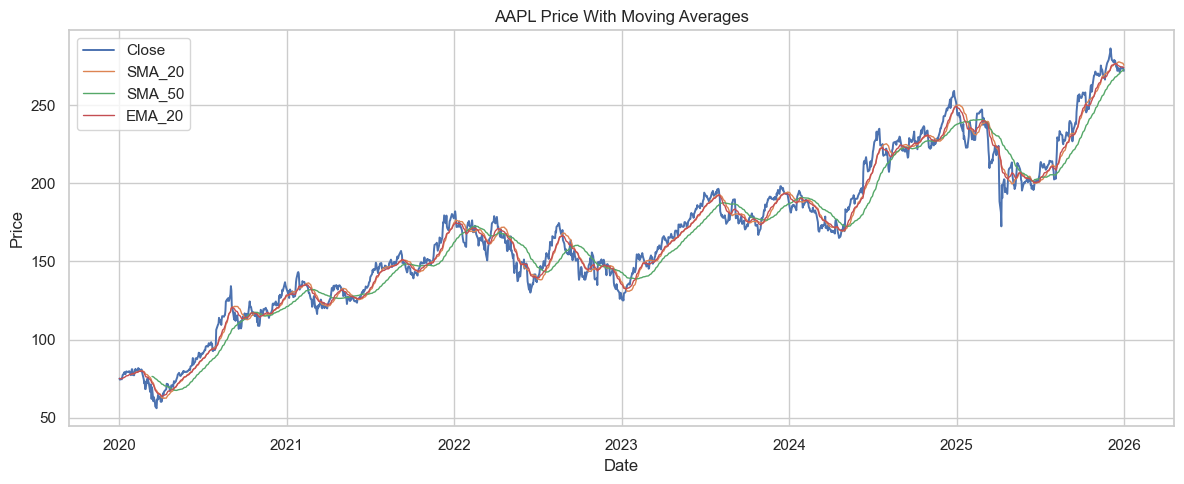

In [8]:
fig, ax = plot_price_indicators(indicators, TICKER)
save_current_figure(FIGURES / f'{TICKER}_moving_averages.png')
plt.show()

#### Figure 1: Price and Moving Averages
The chart below shows the stock's closing price along with 20- and 50-day simple moving averages (SMA). These lines help visualize short- and medium-term price trends. The plot is labeled and referenced for clarity.

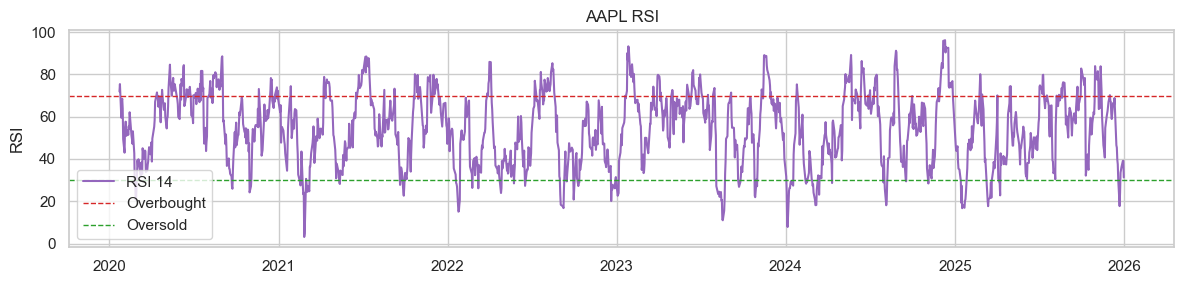

In [9]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(indicators['Date'], indicators['rsi_14'], label='RSI 14', color='tab:purple')
ax.axhline(70, color='tab:red', linestyle='--', linewidth=1, label='Overbought')
ax.axhline(30, color='tab:green', linestyle='--', linewidth=1, label='Oversold')
ax.set_title(f'{TICKER} RSI')
ax.set_ylabel('RSI')
ax.legend()
save_current_figure(FIGURES / f'{TICKER}_rsi.png')
plt.show()

#### Figure 2: Relative Strength Index (RSI)
This plot displays the 14-day RSI for the stock, with horizontal lines at 70 (overbought) and 30 (oversold). RSI helps identify potential reversal points and momentum extremes.

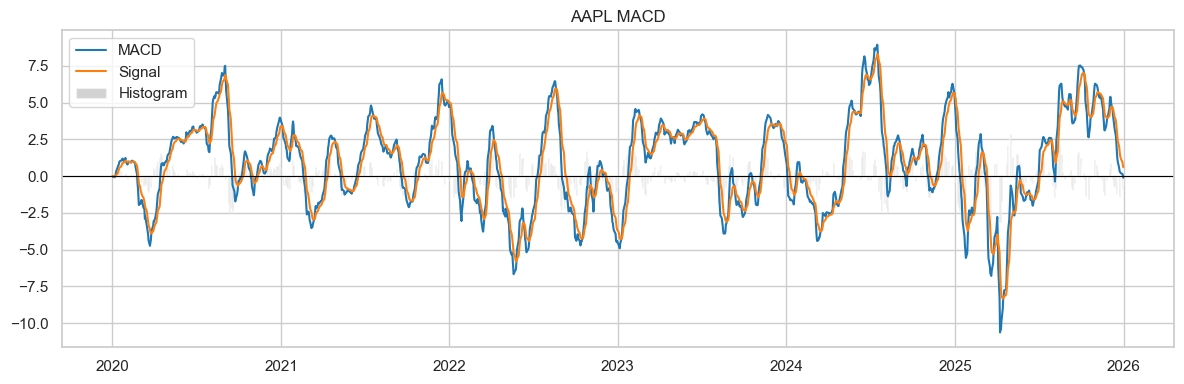

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(indicators['Date'], indicators['macd'], label='MACD', color='tab:blue')
ax.plot(indicators['Date'], indicators['macd_signal'], label='Signal', color='tab:orange')
ax.bar(indicators['Date'], indicators['macd_hist'], label='Histogram', alpha=0.35, color='tab:gray')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'{TICKER} MACD')
ax.legend()
save_current_figure(FIGURES / f'{TICKER}_macd.png')
plt.show()

#### Figure 3: MACD and Signal Line
The following chart shows the MACD, signal line, and histogram. MACD is a momentum indicator that helps identify trend changes and momentum shifts.

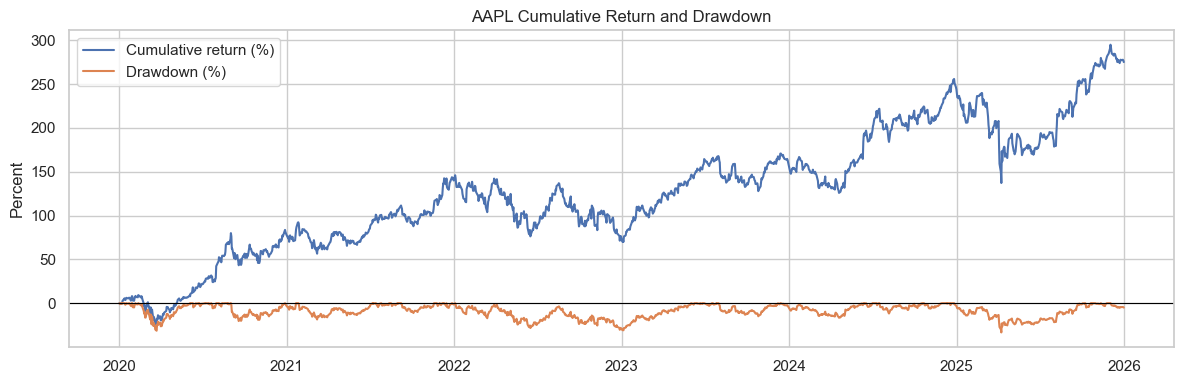

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(risk_metrics['Date'], risk_metrics['cumulative_return'] * 100, label='Cumulative return (%)')
ax.plot(risk_metrics['Date'], risk_metrics['drawdown'] * 100, label='Drawdown (%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'{TICKER} Cumulative Return and Drawdown')
ax.set_ylabel('Percent')
ax.legend()
save_current_figure(FIGURES / f'{TICKER}_risk_return.png')
plt.show()

#### Figure 4: Cumulative Return and Drawdown
This plot shows the cumulative return and drawdown over time, providing insight into the stock's performance and risk periods.

## Interpretation Summary

- TA-Lib is the preferred indicator engine for the final Task 2 workflow; if TA-Lib is unavailable, the code falls back to equivalent pandas calculations and prints the engine used.
- The 20/50-session moving averages show short- versus medium-term trend context and help identify whether the close is trading above or below recent price history.
- The 20-session EMA reacts faster than the SMA and can be used to detect earlier trend changes.
- RSI uses a 14-session window; values above 70 suggest overbought conditions where risk may be reduced, while values below 30 suggest oversold conditions where a rebound watchlist may be reasonable.
- MACD uses 12/26/9 settings; crossovers and histogram sign changes highlight momentum shifts that can be compared later with news sentiment.
- Cumulative return, drawdown, rolling volatility, and Sharpe-style metrics connect the indicators to practical risk management: avoid oversized exposure during high drawdown or volatility periods, and treat sentiment signals as stronger only when technical momentum confirms them.

Data quality note: local CSVs should be preferred for final reproducibility. When `yfinance` is used, record the download date and date range in the final report.
